## Click Through Rate Prediction using XGBoostClassifier in xgboost

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [3]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/34-Click-Through%20Rate%20Prediction/ad_10000records.csv

--2026-03-22 06:31:02--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/34-Click-Through%20Rate%20Prediction/ad_10000records.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1114615 (1.1M) [text/plain]
Saving to: ‘ad_10000records.csv’

ad_10000records.csv 100%[===================>]   1.06M  --.-KB/s    in 0.1s    

2026-03-22 06:31:02 (10.9 MB/s) - ‘ad_10000records.csv’ saved [1114615/1114615]



In [4]:
df = pd.read_csv('ad_10000records.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [5]:
df.shape

(10000, 10)

In [6]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  float64
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  object 
 5   City                      10000 non-null  object 
 6   Gender                    10000 non-null  object 
 7   Country                   10000 non-null  object 
 8   Timestamp                 10000 non-null  object 
 9   Clicked on Ad             10000 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


In [11]:
value_counts = df['Clicked on Ad'].value_counts()
value_counts

,count
Clicked on Ad,
0,5083
1,4917


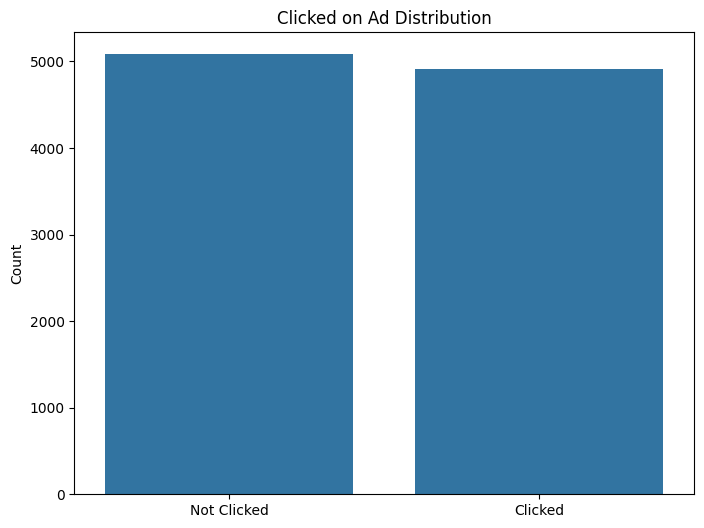

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(x=['Not Clicked', 'Clicked'], y=value_counts)
plt.title('Clicked on Ad Distribution')
plt.ylabel('Count')
plt.show()

In [18]:
click_through_rate = value_counts[1] / 10000 * 100
print(f"The click through rate is: {click_through_rate}%")

The click through rate is: 49.17%


2.  Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

3. Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

X=df.iloc[:,0:7]
X=X.drop(['Ad Topic Line','City'],axis=1)

y=df.iloc[:,9]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### 4. Build and Fit the Model

In [23]:
from xgboost import XGBRFClassifier

model = XGBRFClassifier(random_state=42)
model.fit(X_train, y_train)

XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, objective='binary:logistic',
                random_state=42, ...)

### 5. Make Prediction

In [33]:
test_pred = model.predict(X_test)
test_pred[0] == y_test.iloc[0]

np.False_

In [31]:
train_pred = model.predict(X_train)
train_pred[0] == y_train.iloc[0]

np.True_

### 6. Evaluating the Model

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

training_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {training_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

Training Accuracy: 0.776
Test Accuracy: 0.756


In [35]:
labels = ['Train', 'Test']
accuracy = [training_accuracy, test_accuracy]

/tmp/ipykernel_21146/3422668413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracy, palette=['green', 'blue'])


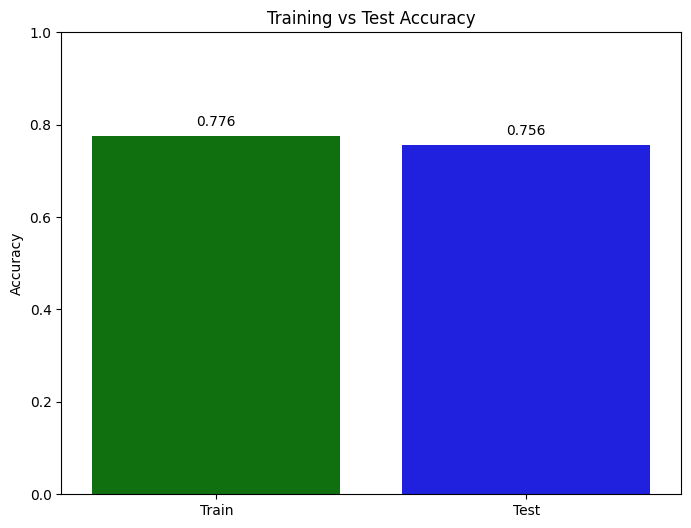

In [36]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=labels, y=accuracy, palette=['green', 'blue'])
plt.title('Training vs Test Accuracy')
plt.ylim(0, max(1, max(accuracy) + 0.05))
plt.ylabel('Accuracy')

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.3f}',
                (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [37]:
cm = confusion_matrix(y_test, test_pred)
cm

array([[848, 166],
       [321, 665]])

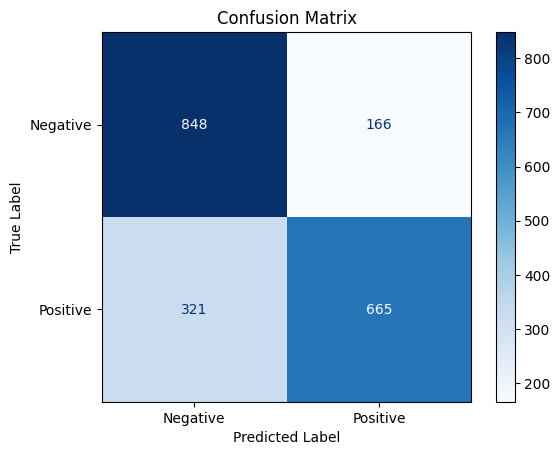

In [38]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
 )
display.plot(cmap='Blues', colorbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()